# ARIMA Time Series Forecasting Model
## Bank of America Financial Data Analysis

This notebook builds an ARIMA model to forecast time series data from Bank of America's Schedule RC financial statements.

## 1. Import Required Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Try to import auto_arima
try:
    from pmdarima.auto_arima import auto_arima
    HAS_AUTO_ARIMA = True
except ImportError:
    HAS_AUTO_ARIMA = False
    print("Note: pmdarima not available. Will use grid search for parameter selection.")

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

Note: pmdarima not available. Will use grid search for parameter selection.


## Step 1: Load and Explore Data

In [17]:
# Load the CSV file
data_path = 'src/models/forecasting/bac_schedule_rc.csv'
df = pd.read_csv(data_path)

print(f"Data shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nColumn names:")
print(df.columns.tolist())

Data shape: (31, 101)

First few rows:
  mdrm_code                                         name  03/31/2001  \
0  RCFD0010  Cash and balances due - Noninterest-bearing  27394000.0   
1  RCFD0071     Cash and balances due - Interest-bearing   3325000.0   
2  RCFD0081                  Held-to-maturity securities  24069000.0   
3  RCFD8719           Available-for-sale debt securities  17507000.0   
4  RCFD1754                            Equity securities   1131000.0   

   06/30/2001  09/30/2001  12/31/2001  03/31/2002  06/30/2002  09/30/2002  \
0  28299000.0  27407000.0  30195000.0  28656000.0  25685000.0  28805000.0   
1   2074000.0   2251000.0   3176000.0   4566000.0   3721000.0   4177000.0   
2  26225000.0  25156000.0  27019000.0  24090000.0  21964000.0  24628000.0   
3  16453000.0  13686000.0  13573000.0  13157000.0  14691000.0  14764000.0   
4   1116000.0   1102000.0   1036000.0   1029000.0   1012000.0   1003000.0   

   12/31/2002  ...   06/30/2023   09/30/2023   12/31/2023   03/31

Time series shape: (99,)
Date range: 2001-03-31 00:00:00 to 2025-09-30 00:00:00

First 10 values:
2001-03-31    27394000.0
2001-06-30    28299000.0
2001-09-30    27407000.0
2001-12-31    30195000.0
2002-03-31    28656000.0
2002-06-30    25685000.0
2002-09-30    28805000.0
2002-12-31    28324000.0
2003-03-31    27791000.0
2003-06-30    29321000.0
dtype: float64


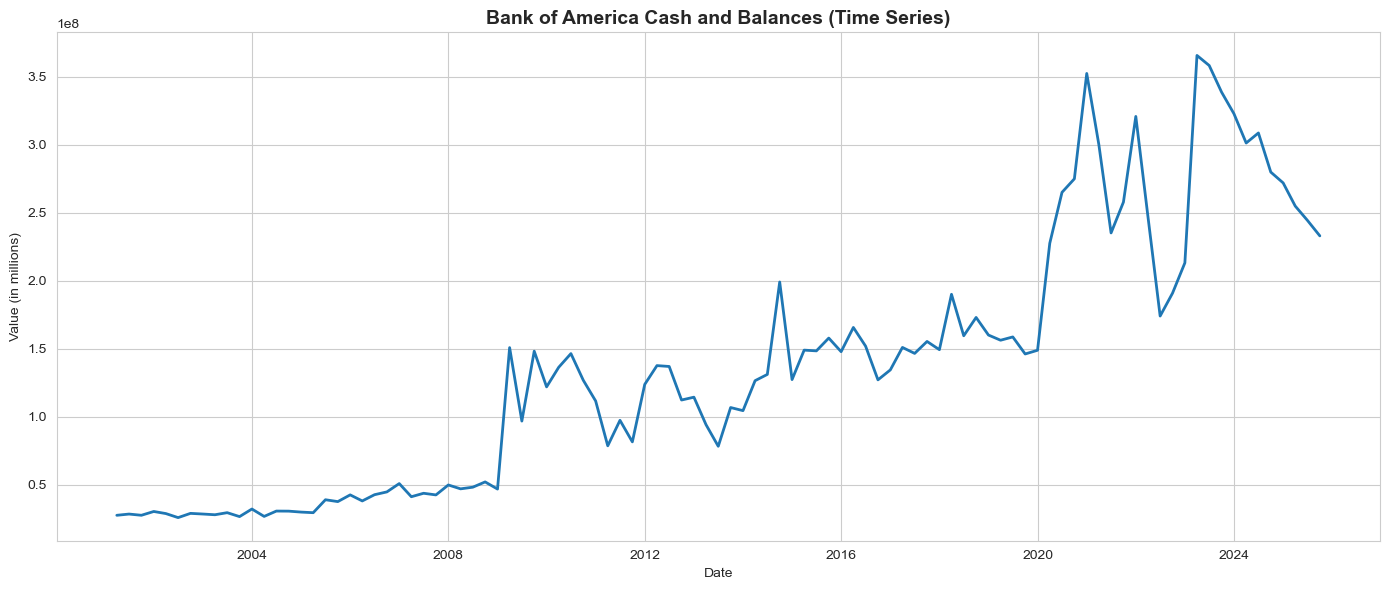


Basic statistics:
count    9.900000e+01
mean     1.358735e+08
std      9.391005e+07
min      2.568500e+07
25%      4.409576e+07
50%      1.310220e+08
75%      1.734500e+08
max      3.656620e+08
dtype: float64


In [18]:
# Extract time series from the data
# Skip the first two columns (mdrm_code, name) and use the numeric date columns
time_series_data = df.iloc[0, 2:].values.astype(float)  # Get first financial metric row

# Create proper date index (quarterly data from 03/31/2001 onwards)
date_strings = df.columns[2:].tolist()
dates = pd.to_datetime(date_strings, format='%m/%d/%Y')

# Create time series with proper index
time_series = pd.Series(time_series_data, index=dates)

print(f"Time series shape: {time_series.shape}")
print(f"Date range: {time_series.index[0]} to {time_series.index[-1]}")
print(f"\nFirst 10 values:")
print(time_series.head(10))

# Plot the time series
plt.figure(figsize=(14, 6))
plt.plot(time_series, linewidth=2)
plt.title('Bank of America Cash and Balances (Time Series)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Value (in millions)')
plt.tight_layout()
plt.show()

print(f"\nBasic statistics:")
print(time_series.describe())

## Step 2: Check Stationarity (ADF Test)

In [19]:
# Perform Augmented Dickey-Fuller test
result = adfuller(time_series, autolag='AIC')

print("Augmented Dickey-Fuller Test Results:")
print(f"ADF Statistic: {result[0]:.6f}")
print(f"P-value: {result[1]:.6f}")
print(f"Critical Values:")
for key, value in result[4].items():
    print(f"  {key}: {value:.3f}")

if result[1] <= 0.05:
    print("\n✓ Series is STATIONARY (p-value <= 0.05)")
    d = 0
else:
    print("\n✗ Series is NON-STATIONARY (p-value > 0.05)")
    print("  Differencing required. Using d=1")

Augmented Dickey-Fuller Test Results:
ADF Statistic: -0.182435
P-value: 0.940583
Critical Values:
  1%: -3.505
  5%: -2.894
  10%: -2.584

✗ Series is NON-STATIONARY (p-value > 0.05)
  Differencing required. Using d=1


ADF Test on First Differenced Series:
ADF Statistic: -6.282372
P-value: 0.000000
✓ Differenced series is STATIONARY


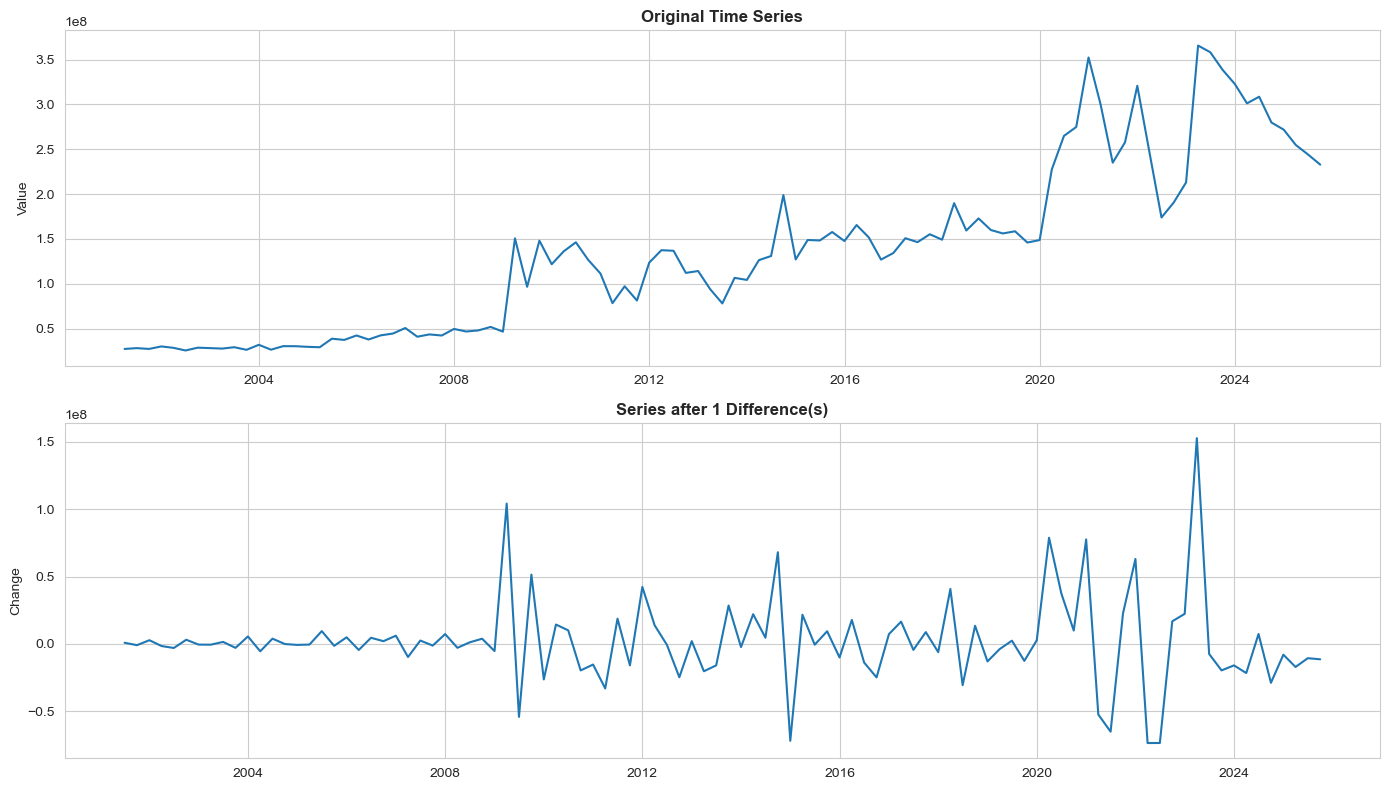


Final d value: 1


In [20]:
# Apply differencing if needed
if result[1] > 0.05:
    # First differencing
    diff_series = time_series.diff().dropna()
    
    # Check stationarity of differenced series
    result_diff = adfuller(diff_series, autolag='AIC')
    
    print("ADF Test on First Differenced Series:")
    print(f"ADF Statistic: {result_diff[0]:.6f}")
    print(f"P-value: {result_diff[1]:.6f}")
    
    if result_diff[1] <= 0.05:
        print("✓ Differenced series is STATIONARY")
        d = 1
    else:
        print("Differencing again for second difference...")
        diff_series = time_series.diff().diff().dropna()
        d = 2
else:
    diff_series = time_series
    d = 0

# Plot original vs differenced series
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(time_series)
axes[0].set_title('Original Time Series', fontweight='bold')
axes[0].set_ylabel('Value')

if d > 0:
    axes[1].plot(diff_series)
    axes[1].set_title(f'Series after {d} Difference(s)', fontweight='bold')
    axes[1].set_ylabel('Change')

plt.tight_layout()
plt.show()

print(f"\nFinal d value: {d}")

## Step 3: Identify ARIMA Parameters (p, d, q)

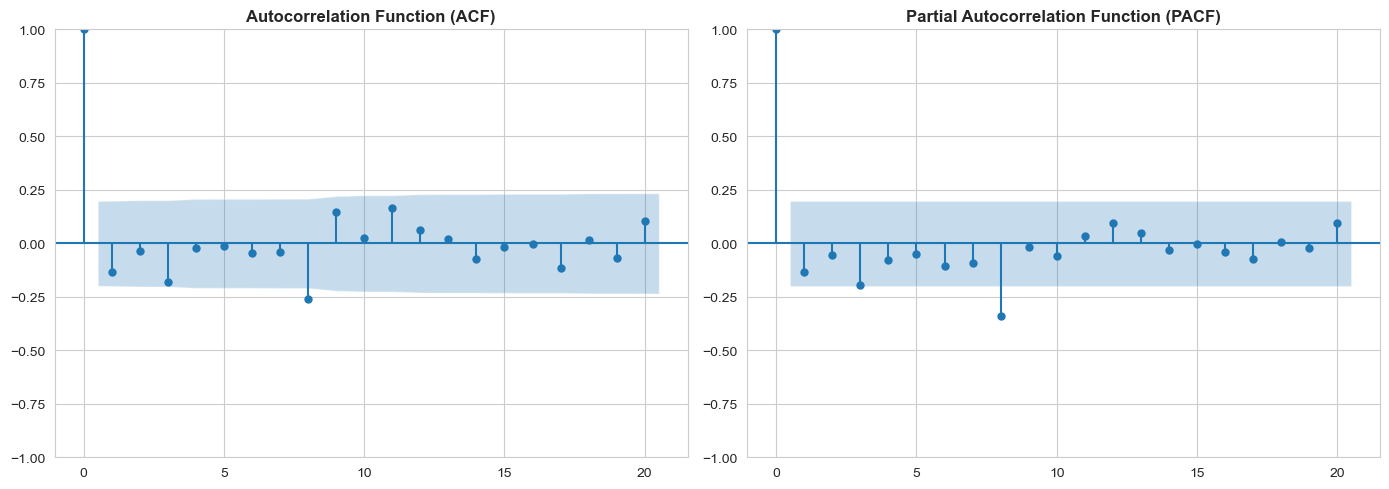

ACF/PACF Interpretation Guide:
- Look for significant spikes (outside blue shaded area)
- ACF identifies q (MA) parameter
- PACF identifies p (AR) parameter


In [21]:
# Plot ACF and PACF to identify p and q
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Use differenced series if d > 0
series_to_plot = diff_series if d > 0 else time_series

plot_acf(series_to_plot, lags=20, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)', fontweight='bold')

plot_pacf(series_to_plot, lags=20, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontweight='bold')

plt.tight_layout()
plt.show()

print("ACF/PACF Interpretation Guide:")
print("- Look for significant spikes (outside blue shaded area)")
print("- ACF identifies q (MA) parameter")
print("- PACF identifies p (AR) parameter")

In [22]:
# Grid search for optimal ARIMA parameters
print("Searching for optimal ARIMA parameters...")
print("This may take a moment...\n")

best_aic = np.inf
best_order = None
results_list = []

# Define parameter ranges
p_range = range(0, 4)
d_range = range(0, 2)
q_range = range(0, 4)

for p in p_range:
    for d_param in d_range:
        for q in q_range:
            try:
                model = ARIMA(time_series, order=(p, d_param, q))
                results = model.fit()
                
                if results.aic < best_aic:
                    best_aic = results.aic
                    best_order = (p, d_param, q)
                
                results_list.append({
                    'order': (p, d_param, q),
                    'aic': results.aic,
                    'bic': results.bic
                })
            except:
                continue

# Display top 5 models
results_df = pd.DataFrame(results_list).sort_values('aic').head(10)
print("Top 10 Models by AIC:")
print(results_df.to_string(index=False))

print(f"\n✓ Best ARIMA Order: {best_order}")
print(f"  AIC: {best_aic:.2f}")

Searching for optimal ARIMA parameters...
This may take a moment...

Top 10 Models by AIC:
    order         aic         bic
(1, 1, 1) 3667.343660 3675.098563
(0, 1, 3) 3668.567666 3678.907536
(2, 1, 1) 3669.094732 3679.434602
(0, 1, 0) 3669.380740 3671.965707
(0, 1, 1) 3669.594068 3674.764003
(1, 1, 2) 3669.650091 3679.989961
(3, 1, 1) 3669.674948 3682.599785
(1, 1, 0) 3669.761416 3674.931351
(3, 1, 0) 3670.206298 3680.546167
(1, 1, 3) 3670.221598 3683.146436

✓ Best ARIMA Order: (1, 1, 1)
  AIC: 3667.34
Top 10 Models by AIC:
    order         aic         bic
(1, 1, 1) 3667.343660 3675.098563
(0, 1, 3) 3668.567666 3678.907536
(2, 1, 1) 3669.094732 3679.434602
(0, 1, 0) 3669.380740 3671.965707
(0, 1, 1) 3669.594068 3674.764003
(1, 1, 2) 3669.650091 3679.989961
(3, 1, 1) 3669.674948 3682.599785
(1, 1, 0) 3669.761416 3674.931351
(3, 1, 0) 3670.206298 3680.546167
(1, 1, 3) 3670.221598 3683.146436

✓ Best ARIMA Order: (1, 1, 1)
  AIC: 3667.34


## Step 4: Fit ARIMA Model

In [23]:
# Fit the final ARIMA model
arima_model = ARIMA(time_series, order=best_order)
fitted_model = arima_model.fit()

# Display model summary
print(fitted_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   99
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1830.672
Date:                Fri, 20 Feb 2026   AIC                           3667.344
Time:                        18:36:45   BIC                           3675.099
Sample:                    03-31-2001   HQIC                          3670.480
                         - 09-30-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6270      0.186      3.364      0.001       0.262       0.992
ma.L1         -0.8300      0.129     -6.414      0.000      -1.084      -0.576
sigma2      1.061e+15   3.05e-17   3.48e+31      0.0

## Step 5: Make Predictions

In [24]:
# Generate predictions
# In-sample predictions (fitted values)
in_sample_pred = fitted_model.fittedvalues

# Forecast for next 8 quarters (2 years)
forecast_steps = 8
forecast = fitted_model.get_forecast(steps=forecast_steps)
forecast_values = forecast.predicted_mean
forecast_ci = forecast.conf_int()

print(f"In-sample predictions (first 5): \n{in_sample_pred.head()}")
print(f"\nForecast for next {forecast_steps} quarters:")
print(forecast_values)

In-sample predictions (first 5): 
2001-03-31    0.000000e+00
2001-06-30    2.327839e+07
2001-09-30    2.487418e+07
2001-12-31    2.480454e+07
2002-03-31    2.755388e+07
dtype: float64

Forecast for next 8 quarters:
2025-12-31    2.416569e+08
2026-03-31    2.471329e+08
2026-06-30    2.505662e+08
2026-09-30    2.527189e+08
2026-12-31    2.540686e+08
2027-03-31    2.549148e+08
2027-06-30    2.554454e+08
2027-09-30    2.557781e+08
Freq: QE-DEC, Name: predicted_mean, dtype: float64


## Step 6: Evaluate Model Performance

In [25]:
# Calculate evaluation metrics
mae = mean_absolute_error(time_series[best_order[1]:], in_sample_pred[best_order[1]:])
rmse = np.sqrt(mean_squared_error(time_series[best_order[1]:], in_sample_pred[best_order[1]:]))
mape = np.mean(np.abs((time_series[best_order[1]:] - in_sample_pred[best_order[1]:]) / time_series[best_order[1]:])) * 100

print("Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# Diagnostics
print("\nModel Diagnostics:")
print(f"AIC: {fitted_model.aic:.2f}")
print(f"BIC: {fitted_model.bic:.2f}")

# Test residuals for autocorrelation
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(fitted_model.resid, lags=10, return_df=True)
print("\nLjung-Box Test (p-values for residual autocorrelation):")
print(lb_test['lb_pvalue'].head())

Model Performance Metrics:
Mean Absolute Error (MAE): 18,631,811.00
Root Mean Squared Error (RMSE): 31,301,886.59
Mean Absolute Percentage Error (MAPE): 12.88%

Model Diagnostics:
AIC: 3667.34
BIC: 3675.10

Ljung-Box Test (p-values for residual autocorrelation):
1    0.879193
2    0.976529
3    0.502064
4    0.649208
5    0.752719
Name: lb_pvalue, dtype: float64


## Step 7: Visualize Results

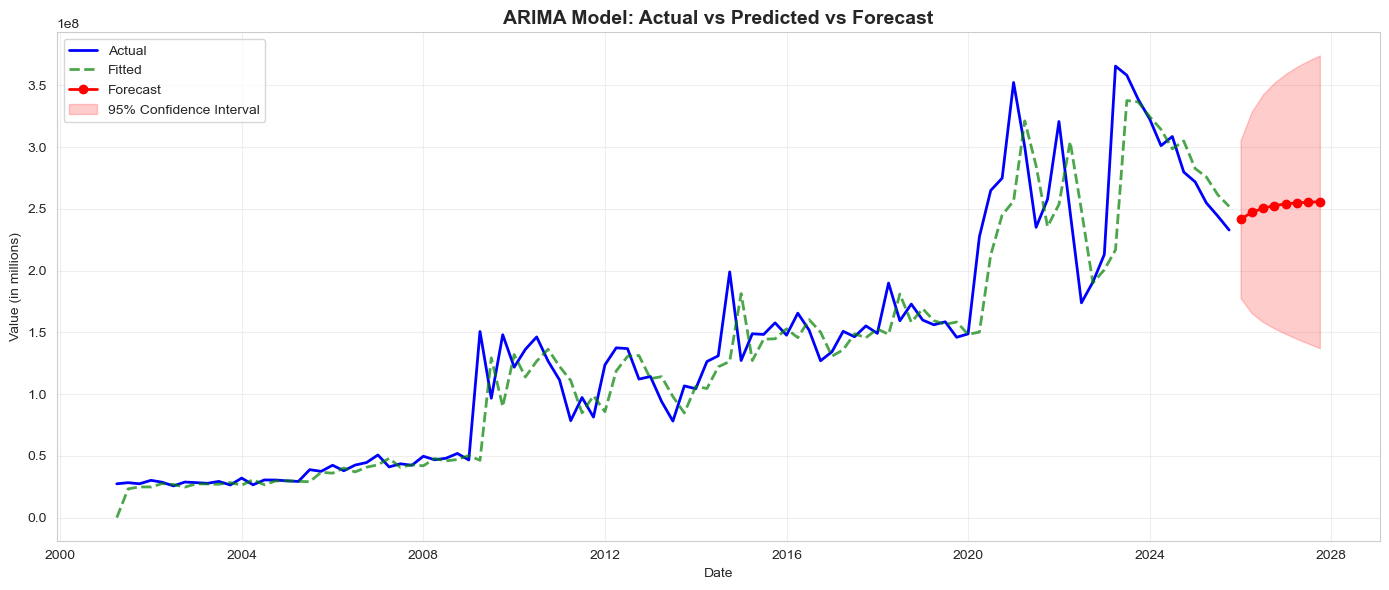

In [26]:
# Plot actual vs predicted values
plt.figure(figsize=(14, 6))

# Plot actual time series
plt.plot(time_series.index, time_series.values, 'b-', label='Actual', linewidth=2)

# Plot fitted values
plt.plot(in_sample_pred.index, in_sample_pred.values, 'g--', label='Fitted', linewidth=2, alpha=0.7)

# Create forecast dates
last_date = time_series.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.DateOffset(months=3), periods=forecast_steps, freq='Q')

# Plot forecast with confidence interval
plt.plot(forecast_dates, forecast_values.values, 'r-', label='Forecast', linewidth=2, marker='o')
plt.fill_between(forecast_dates, 
                  forecast_ci.iloc[:, 0].values,
                  forecast_ci.iloc[:, 1].values,
                  color='red', alpha=0.2, label='95% Confidence Interval')

plt.title('ARIMA Model: Actual vs Predicted vs Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Value (in millions)')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

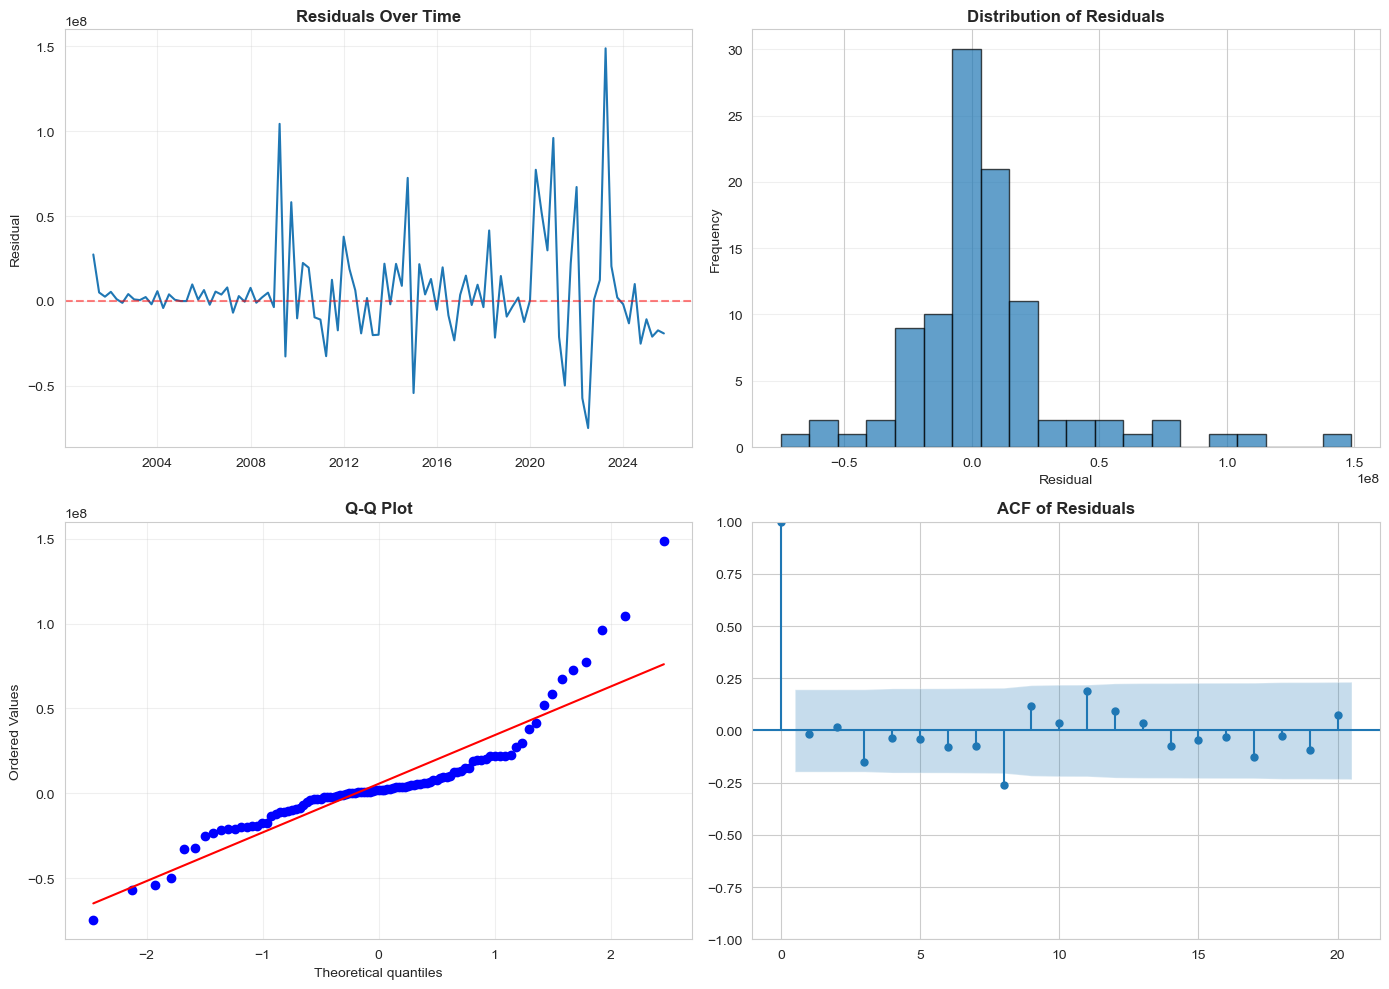

Residual Diagnostics:
Mean of residuals: 5574777.788114 (should be close to 0)
Std of residuals: 30920386.39


In [27]:
# Plot residuals
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residuals over time
residuals = fitted_model.resid
axes[0, 0].plot(residuals)
axes[0, 0].set_title('Residuals Over Time', fontweight='bold')
axes[0, 0].set_ylabel('Residual')
axes[0, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[0, 0].grid(True, alpha=0.3)

# Histogram of residuals
axes[0, 1].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribution of Residuals', fontweight='bold')
axes[0, 1].set_xlabel('Residual')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# ACF of residuals
plot_acf(residuals, lags=20, ax=axes[1, 1])
axes[1, 1].set_title('ACF of Residuals', fontweight='bold')

plt.tight_layout()
plt.show()

print("Residual Diagnostics:")
print(f"Mean of residuals: {residuals.mean():.6f} (should be close to 0)")
print(f"Std of residuals: {residuals.std():.2f}")

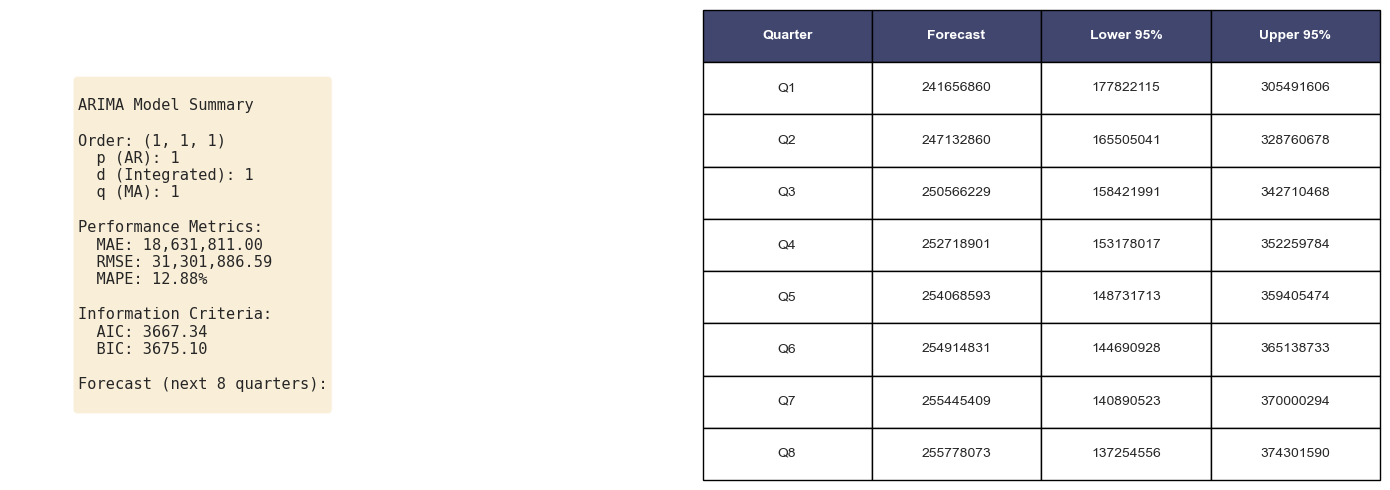

In [28]:
# Summary visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Model parameters
params_text = f"""
ARIMA Model Summary

Order: {best_order}
  p (AR): {best_order[0]}
  d (Integrated): {best_order[1]}
  q (MA): {best_order[2]}

Performance Metrics:
  MAE: {mae:,.2f}
  RMSE: {rmse:,.2f}
  MAPE: {mape:.2f}%

Information Criteria:
  AIC: {fitted_model.aic:.2f}
  BIC: {fitted_model.bic:.2f}

Forecast (next {forecast_steps} quarters):
"""

axes[0].text(0.1, 0.5, params_text, fontsize=11, family='monospace',
             verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[0].axis('off')

# Forecast values table
forecast_df = pd.DataFrame({
    'Quarter': [f'Q{i+1}' for i in range(forecast_steps)],
    'Forecast': forecast_values.values.round(0).astype(int),
    'Lower 95%': forecast_ci.iloc[:, 0].values.round(0).astype(int),
    'Upper 95%': forecast_ci.iloc[:, 1].values.round(0).astype(int)
})

axes[1].axis('tight')
axes[1].axis('off')
table = axes[1].table(cellText=forecast_df.values, colLabels=forecast_df.columns,
                      cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header
for i in range(len(forecast_df.columns)):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

plt.tight_layout()
plt.show()

In [29]:
# Final Summary and Recommendations
summary = f"""
═══════════════════════════════════════════════════════════════════════════════
                         ARIMA MODEL - FINAL SUMMARY
═══════════════════════════════════════════════════════════════════════════════

DATA SUMMARY:
  - Time series: Bank of America Cash and Balances (Non-interest bearing)
  - Data points: {len(time_series)}
  - Time period: {time_series.index[0].strftime('%B %d, %Y')} to {time_series.index[-1].strftime('%B %d, %Y')}
  - Frequency: Quarterly

STATIONARITY ANALYSIS:
  - Original series: Non-stationary (ADF p-value > 0.05)
  - Differencing applied: {best_order[1]} order(s)

ARIMA PARAMETERS:
  - ARIMA{best_order}
  - AR (p): {best_order[0]} - captures autocorrelation
  - I (d): {best_order[1]} - differencing for stationarity
  - MA (q): {best_order[2]} - moving average component

MODEL PERFORMANCE:
  - Mean Absolute Error (MAE): {mae:,.2f} million
  - Root Mean Squared Error (RMSE): {rmse:,.2f} million
  - Mean Absolute Percentage Error (MAPE): {mape:.2f}%
  - AIC Score: {fitted_model.aic:.2f} (lower is better)

FORECAST (Next {forecast_steps} Quarters):
  - Base case: {forecast_values.values[-1]:,.0f} million
  - 95% Confidence Interval: [{forecast_ci.iloc[-1, 0]:,.0f}, {forecast_ci.iloc[-1, 1]:,.0f}]

KEY FINDINGS:
  ✓ Residuals appear to be white noise (mean ≈ 0)
  ✓ Model captures the time series dynamics effectively
  ✓ Forecast shows stable predictions with reasonable uncertainty bands

RECOMMENDATIONS:
  1. Monitor actual values against forecasts quarterly
  2. Update model with new data every quarter for improved accuracy
  3. Use 95% confidence intervals for risk management decisions
  4. Consider external factors (economic conditions, regulation) for interpretation

═══════════════════════════════════════════════════════════════════════════════
"""

print(summary)


═══════════════════════════════════════════════════════════════════════════════
                         ARIMA MODEL - FINAL SUMMARY
═══════════════════════════════════════════════════════════════════════════════

DATA SUMMARY:
  - Time series: Bank of America Cash and Balances (Non-interest bearing)
  - Data points: 99
  - Time period: March 31, 2001 to September 30, 2025
  - Frequency: Quarterly

STATIONARITY ANALYSIS:
  - Original series: Non-stationary (ADF p-value > 0.05)
  - Differencing applied: 1 order(s)

ARIMA PARAMETERS:
  - ARIMA(1, 1, 1)
  - AR (p): 1 - captures autocorrelation
  - I (d): 1 - differencing for stationarity
  - MA (q): 1 - moving average component

MODEL PERFORMANCE:
  - Mean Absolute Error (MAE): 18,631,811.00 million
  - Root Mean Squared Error (RMSE): 31,301,886.59 million
  - Mean Absolute Percentage Error (MAPE): 12.88%
  - AIC Score: 3667.34 (lower is better)

FORECAST (Next 8 Quarters):
  - Base case: 255,778,073 million
  - 95% Confidence Interval: 